# Exploratory Data Analysis

This notebook explores the final preprocessed mental health text dataset prior to feature engineering and machine learning model development. The analysis examines class distribution, text length characteristics, frequently occurring words, common bigrams, and selected vocabulary patterns within the Neutral, Depression, and Suicidal Tendencies classes.

In [256]:
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

### Load the dataset

In [257]:
# Load preprocessed dataset
df = pd.read_csv("../data/processed/mental_health_text_preprocessed.csv")

### Validate the dataset

In [258]:
# Convert labels to integers
df["Label"] = df["Label"].astype(int)

In [259]:
# Confirm and validate data
print(df.shape)
display(df.head())
display(df.info())
display(df.isna().sum())
display(df["Label"].value_counts())

# Verify no duplicates
print(df.duplicated().sum())

(15774, 8)


,Label,TEXT,character_count,word_count,TEXT_ORIGINAL,TEXT_REPAIRED,TEXT_NORMALIZED,TEXT_PROCESSED
0,0,TIL the movie Starship Troopers was never adap...,89,14,TIL the movie Starship Troopers was never adap...,TIL the movie Starship Troopers was never adap...,TIL the movie Starship Troopers was never adap...,til movie starship troopers never adapt succes...
1,0,What do you call a fat baby?,28,7,What do you call a fat baby?,What do you call a fat baby?,What do you call a fat baby?,fat baby
2,0,Two morons are sitting on a fence. The big one...,78,16,Two morons are sitting on a fence. The big one...,Two morons are sitting on a fence. The big one...,Two morons are sitting on a fence. The big one...,number moron sit fence big number fall not
3,0,I covered all my weapons in glue.,33,7,I covered all my weapons in glue.,I covered all my weapons in glue.,I covered all my weapons in glue.,cover weapon glue
4,0,Joke I made up: Caveman and a bear walk into a...,103,19,Joke I made up: Caveman and a bear walk into a...,Joke I made up: Caveman and a bear walk into a...,Joke I made up: Caveman and a bear walk into a...,joke caveman bear walk bar ba ender say story ...


<class 'pandas.DataFrame'>
RangeIndex: 15774 entries, 0 to 15773
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Label            15774 non-null  int64
 1   TEXT             15774 non-null  str  
 2   character_count  15774 non-null  int64
 3   word_count       15774 non-null  int64
 4   TEXT_ORIGINAL    15774 non-null  str  
 5   TEXT_REPAIRED    15774 non-null  str  
 6   TEXT_NORMALIZED  15774 non-null  str  
 7   TEXT_PROCESSED   15774 non-null  str  
dtypes: int64(3), str(5)
memory usage: 986.0 KB


None

Label              0
TEXT               0
character_count    0
word_count         0
TEXT_ORIGINAL      0
TEXT_REPAIRED      0
TEXT_NORMALIZED    0
TEXT_PROCESSED     0
dtype: int64

Label
0    6032
2    5446
1    4296
Name: count, dtype: int64

0


## Dataset Validation Results

The final preprocessed dataset was successfully loaded and validated prior to exploratory data analysis. Validation confirmed the dataset dimensions, data types, missing values, duplicate records, and class distribution. The dataset contains the final processed text that will be used throughout the exploratory analysis, feature engineering, and machine learning stages of the project.

### Create readable class names

In [260]:
# Map numeric labels to class names

label_map = {0: "Neutral", 1: "Depression", 2: "Suicidal Tendencies"}

df["Class"] = df["Label"].map(label_map)

display(df[["Label", "Class"]].head())

,Label,Class
0,0,Neutral
1,0,Neutral
2,0,Neutral
3,0,Neutral
4,0,Neutral


## Class Distribution

Understanding the distribution of observations across the three target classes is an important first step in exploratory data analysis. Examining the class frequencies helps identify whether the dataset is balanced or imbalanced, which can influence model training, evaluation, and interpretation.

In [261]:
# Calculate class counts and percentages

class_counts = df["Class"].value_counts().sort_index()

class_percent = (class_counts / len(df) * 100).round(2)

class_summary = pd.DataFrame({"Count": class_counts, "Percentage (%)": class_percent})

display(class_summary)

,Count,Percentage (%)
Class,,
Depression,4296,27.23
Neutral,6032,38.24
Suicidal Tendencies,5446,34.53


### Class Distribution Bar Chart

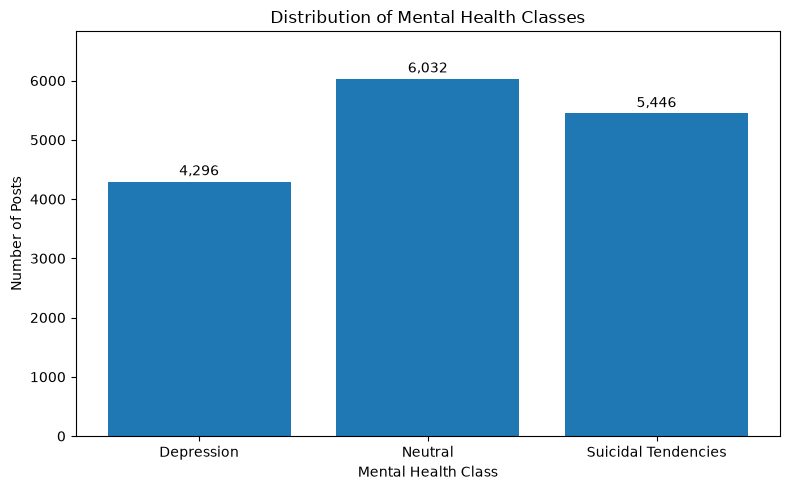

In [262]:
plt.figure(figsize=(8, 5))

bars = plt.bar(class_summary.index, class_summary["Count"])

plt.title("Distribution of Mental Health Classes")
plt.xlabel("Mental Health Class")
plt.ylabel("Number of Posts")

# Increase space above the tallest bar
plt.ylim(0, max(class_summary["Count"]) + 800)

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 50,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

### Results

The final preprocessed dataset contains **15,774** social media posts across three mental health classification categories. Figure 1 illustrates the distribution of observations among the three classes.

The **Neutral** class contains the largest number of posts with **6,032** observations (**38.24%**), followed by **Suicidal Tendencies** with **5,446** observations (**34.53%**), and **Depression** with **4,296** observations (**27.24%**).

Although the classes are not perfectly balanced, each category contains several thousand observations. The relatively balanced class distribution provides an appropriate foundation for supervised machine learning classification and reduces the likelihood that model performance will be substantially influenced by severe class imbalance. No class-balancing techniques, such as oversampling or undersampling, were considered necessary prior to model development.

## Text Length Analysis

This section examines the distribution of text lengths within the final preprocessed dataset. Summary statistics for both character count and word count are reviewed to better understand the variability in post length prior to feature engineering and model development.

In [263]:
# Summary statistics for text length
display(df[["character_count", "word_count"]].describe())

,character_count,word_count
count,15774.000000,15774.000000
mean,528.442057,99.340180
std,1054.090233,185.465312
min,1.000000,1.000000
25%,42.000000,8.000000
50%,112.000000,21.000000
75%,646.000000,126.000000
max,25558.000000,4834.000000


### Text Length by Mental Health Class

To determine whether posting behavior differs across the three target classes, descriptive statistics for character count and word count were calculated separately for each mental health category.

In [264]:
# Summary statistics by mental health class
display(df.groupby("Class")[["character_count", "word_count"]].describe().round(2))

character_count                                       \
                              count    mean      std  min     25%    50%   
Class                                                                      
Depression                   4296.0  871.84  1114.68  4.0  237.75  586.5   
Neutral                      6032.0   80.70   174.39  1.0   31.00   48.0   
Suicidal Tendencies          5446.0  753.48  1356.13  2.0   46.00  312.0   

                                      word_count                             \
                         75%      max      count    mean     std  min   25%   
Class                                                                         
Depression           1150.25  17931.0     4296.0  158.83  153.66  1.0  47.0   
Neutral                78.00   6864.0     6032.0   15.15   32.53  1.0   6.0   
Suicidal Tendencies   965.75  25558.0     5446.0  145.66  258.95  1.0   9.0   

                                           
                       50%    75%     max  
Class                                      
Depression           114.0  222.0  1630.0  
Neutral                9.0   15.0  1320.0  
Suicidal Tendencies   61.0  187.0  4834.0

### Word Count Distribution by Mental Health Class

A boxplot was created to compare the distribution of word counts across the three mental health classes. Boxplots summarize the median, interquartile range (IQR), overall spread, and potential outliers, providing a visual comparison of text length between classes.

<Figure size 900x600 with 0 Axes>

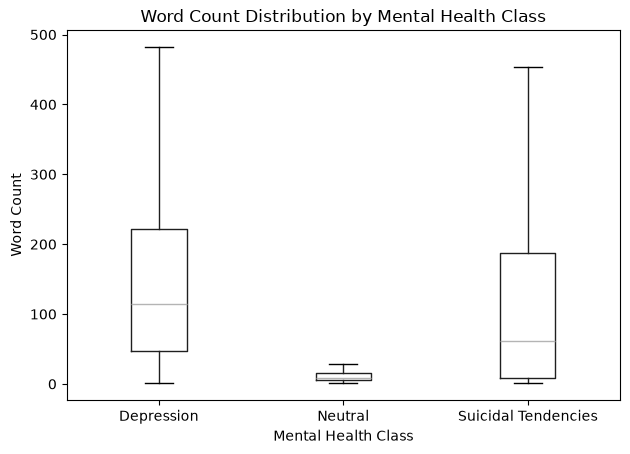

In [265]:
plt.figure(figsize=(9, 6))

df.boxplot(column="word_count", by="Class", grid=False, showfliers=False)

plt.title("Word Count Distribution by Mental Health Class")
plt.suptitle("")
plt.xlabel("Mental Health Class")
plt.ylabel("Word Count")

plt.tight_layout()
plt.show()

### Results
The boxplot illustrates the distribution of word counts across the three mental health classes. Depression posts exhibited the highest median word count (114 words), followed by Suicidal Tendencies (61 words), while Neutral posts were substantially shorter with a median of 9 words. The wider interquartile ranges observed for Depression and Suicidal Tendencies indicate greater variability in post length compared with the Neutral class.

## Most Frequent Words

This section identifies the most frequently occurring words across the final preprocessed dataset. Examining common vocabulary helps confirm that preprocessing was successful and provides an overview of the language represented in the dataset prior to feature engineering.

In [266]:
# Combine all processed text
all_words = " ".join(df["TEXT_PROCESSED"]).split()

# Count word frequencies
word_counts = Counter(all_words)

# Display the 20 most common words
top_words = pd.DataFrame(word_counts.most_common(20), columns=["Word", "Frequency"])

display(top_words)

,Word,Frequency
0,not,36395
1,number,21036
2,want,10242
3,no,8029
4,life,7181
5,like,7066
6,know,6971
7,feel,6640
8,year,6496
9,live,5736


### Results

The most frequently occurring words confirm that preprocessing was successful. Common stop words are absent from the vocabulary, while important negation terms such as **not** and **no** remain because they were intentionally preserved during preprocessing. The placeholder token **number** also appears frequently because all numeric values were standardized during text normalization. Overall, the vocabulary consists primarily of meaningful words associated with personal experiences, emotions, and mental health discussions.

## Bigram Analysis

This section examines the most frequently occurring two-word combinations (bigrams) in the preprocessed text. Unlike individual word frequencies, bigrams preserve limited word order and context, allowing common phrases and linguistic patterns to be identified within the dataset. These patterns may provide additional insight into the language associated with each mental health category and inform subsequent feature engineering.

In [267]:
# Create bigrams from the entire dataset

vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=20)

X = vectorizer.fit_transform(df["TEXT_PROCESSED"])

bigram_counts = (
    pd.DataFrame(
        {
            "Bigram": vectorizer.get_feature_names_out(),
            "Frequency": X.toarray().sum(axis=0),
        }
    )
    .sort_values("Frequency", ascending=False)
    .reset_index(drop=True)
)

display(bigram_counts)

,Bigram,Frequency
0,number year,4000
1,not want,3515
2,not know,3454
3,feel like,1926
4,year old,1717
5,no number,1613
6,sta ed,1308
7,number number,1210
8,want die,1183
9,want live,1019


### Results

The most frequently occurring bigrams demonstrate that the preprocessing pipeline successfully preserved meaningful word order while reducing textual noise. Common phrases such as **feel like**, **want die**, **commit suicide**, and **not understand** provide greater contextual information than individual words alone. These findings suggest that multi-word expressions may contain useful information for distinguishing between mental health categories during feature engineering and model development.

## Depression Word Cloud

A word cloud was generated to provide a qualitative visualization of the most frequently occurring words within the Depression class. Word size represents relative frequency, with larger words appearing more often in the processed text.

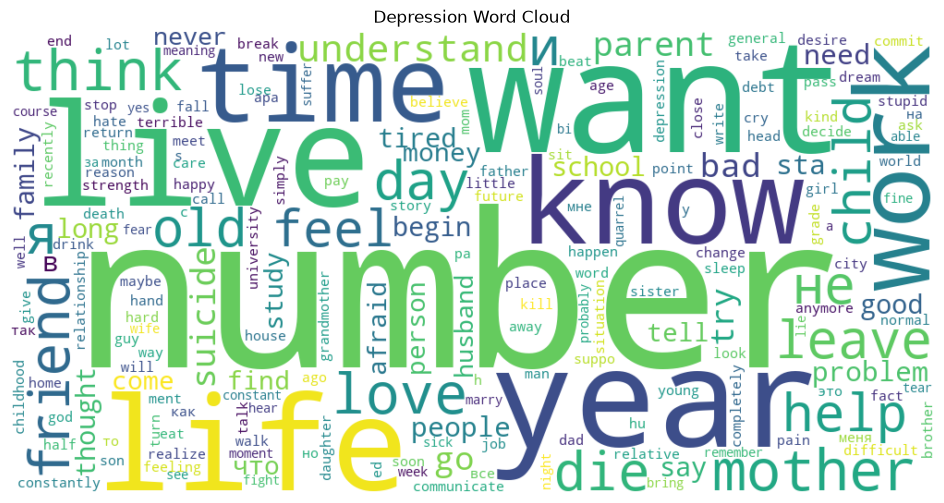

In [268]:
# Combine all Depression text
depression_text = " ".join(df[df["Class"] == "Depression"]["TEXT_PROCESSED"])

# Generate word cloud
wordcloud = WordCloud(
    width=1000, height=500, background_color="white", collocations=False
).generate(depression_text)

# Display
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Depression Word Cloud")
plt.show()

### Results

The Depression word cloud provides a visual summary of the most frequently occurring words within Depression posts after preprocessing. Larger words indicate greater frequency. While the word cloud offers a useful qualitative overview of the vocabulary, quantitative analyses such as frequency tables and bigram analysis provide more detailed insight into the language characteristics of the dataset.

## Exploratory Data Analysis Summary

This exploratory data analysis examined the final preprocessed mental health text dataset prior to feature engineering and machine learning model development.

Key findings include:

- The dataset contains 15,774 observations distributed across three mental health classes.
- The class distribution is reasonably balanced for supervised learning.
- Depression posts exhibit the highest median word count, while Neutral posts are substantially shorter.
- Word frequency analysis confirmed that preprocessing successfully removed stop words while preserving important negation terms.
- Bigram analysis demonstrated that meaningful multi-word expressions were retained after preprocessing.

These findings provide a foundation for the feature engineering stage, where textual data will be transformed into numerical representations suitable for machine learning algorithms.